# Simulation of Quantum Algorithms using Qiskit

## Abstract

In this project, we study fundamental concepts and algorithms in quantum computation using simulations in Qiskit. We begin by exploring basic quantum phenomena such as superposition, entanglement (Bell and GHZ states), and interference.

We then implement two key quantum algorithms: the Quantum Fourier Transform (QFT) and Quantum Phase Estimation (QPE). Using these implementations, we investigate how accurately QPE can estimate an unknown phase.

A systematic analysis is performed by varying the number of qubits and the phase values. We study how the estimation error changes with increasing qubits and observe that the error decreases exponentially. This behavior is further confirmed by plotting log(error) against the number of qubits and fitting the data.

We also examine how the convergence of QPE depends on the binary representation of the phase, showing that phases with exact binary forms are estimated more efficiently than non-terminating ones.


## Introduction

Quantum computation leverages principles of quantum mechanics such as superposition, entanglement, and interference to perform computations that can outperform classical methods for specific problems.

In this notebook, we explore:
- Preparation of quantum states
- Entanglement (Bell and GHZ states)
- Quantum interference
- Quantum Fourier Transform (QFT)
- Quantum Phase Estimation (QPE)

The goal is to develop both conceptual understanding and practical implementation skills using Qiskit.

## Mathematical Background

A quantum state of an n-qubit system is represented as a vector in a $2^n$-dimensional Hilbert space:

$|\psi⟩ = \sum_i c_i |i⟩$

where $c_i$ are complex amplitudes satisfying normalization.

### Key Concepts

- **Superposition**: A qubit exists in a linear combination of |0⟩ and |1⟩.
- **Entanglement**: Composite systems exhibit correlations that cannot be described classically.
- **Measurement**: Collapses the quantum state probabilistically.

### Quantum Gates

- Hadamard (H): Creates superposition  
- CNOT: Generates entanglement  
- Phase Gates: Introduces relative phase  

These gates form the building blocks of quantum circuits.

## Bell State Preparation

Bell states are maximally entangled two-qubit states. One such state is:

$|\Phi^+⟩ = (|00⟩ + |11⟩)/√2$

### Objective
To prepare and verify entanglement using quantum circuits.

### Method
We apply:
1. Hadamard gate on the first qubit
2. CNOT gate between the two qubits

### Expected Outcome
Measurement results should show strong correlation between qubits.


## Superposition and Measurement

Construct a 3-qubit quantum circuit.

**Instructions:**

* Initialize all qubits in the state $|0\rangle$
* Apply Hadamard gates to all qubits
* Measure all qubits

The task is to simulate the circuit and obtain the counts of the measurements. We should be able to explain the reson why all outcomes occur with equal proabilities. 

* Since the Hadamard gate produces an equal superposition off the qubits, so we get the outcomes with equal probabilities.
---


        ┌───┐ ░ ┌─┐      
   q_0: ┤ H ├─░─┤M├──────
        ├───┤ ░ └╥┘┌─┐   
   q_1: ┤ H ├─░──╫─┤M├───
        ├───┤ ░  ║ └╥┘┌─┐
   q_2: ┤ H ├─░──╫──╫─┤M├
        └───┘ ░  ║  ║ └╥┘
   c: 3/═════════╬══╬══╬═
                 ║  ║  ║ 
meas: 3/═════════╩══╩══╩═
                 0  1  2 


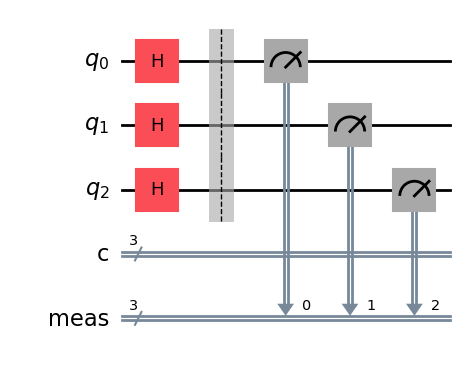

In [ ]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(3, 3) 

qc.h(0) 
qc.h(1) 
qc.h(2) 

#qc.measure([0,1,2], [0,1,2]) 
qc.measure_all() 

print(qc) 

qc.draw("mpl") 


In [ ]:
from qiskit_aer import Aer
from qiskit import transpile
simulator = Aer.get_backend('qasm_simulator') 

qc = QuantumCircuit(3) 
qc.h([0,1,2]) 
qc.measure_all() 

sim = Aer.get_backend('aer_simulator') 

compiled = transpile(qc, sim) 

result = sim.run(compiled, shots=1024).result() 
#result = sim.run(compiled, shots=10000).result() 

counts = result.get_counts()  
print(counts)

{'001': 143, '110': 113, '000': 137, '101': 132, '011': 134, '010': 129, '111': 119, '100': 117}


Statevector:
Statevector([0.35355339+0.j, 0.35355339+0.j, 0.35355339+0.j,
             0.35355339+0.j, 0.35355339+0.j, 0.35355339+0.j,
             0.35355339+0.j, 0.35355339+0.j],
            dims=(2, 2, 2))

Probabilities:
{np.str_('000'): np.float64(0.12499999999999994), np.str_('001'): np.float64(0.12499999999999994), np.str_('010'): np.float64(0.12499999999999994), np.str_('011'): np.float64(0.12499999999999994), np.str_('100'): np.float64(0.12499999999999994), np.str_('101'): np.float64(0.12499999999999994), np.str_('110'): np.float64(0.12499999999999994), np.str_('111'): np.float64(0.12499999999999994)}


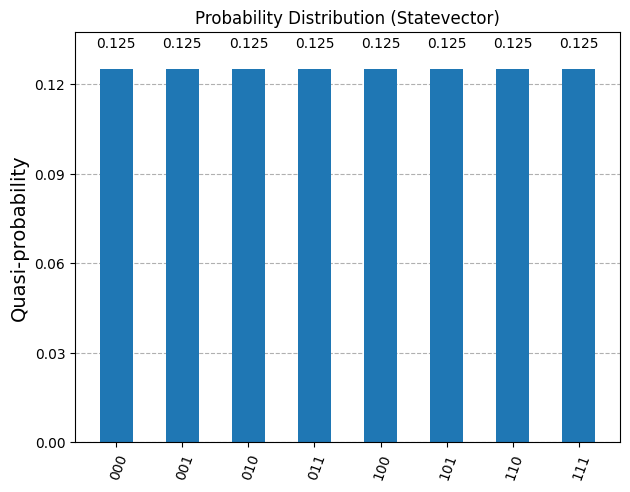


Counts:
{'100': 121, '110': 125, '011': 133, '111': 134, '000': 133, '101': 109, '010': 141, '001': 128}


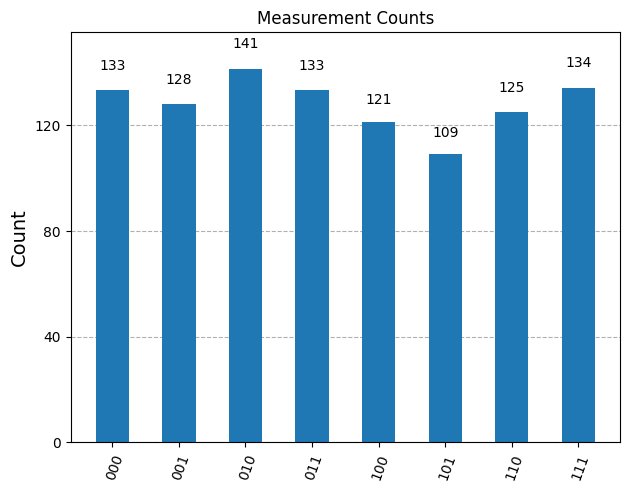

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt  
import numpy as np

import matplotlib.pyplot as plt  
%matplotlib inline 
 
qc = QuantumCircuit(3)
qc.h([0, 1, 2])

state = Statevector.from_instruction(qc)

print("Statevector:")
print(state)

probs = state.probabilities_dict() 
print("\nProbabilities:")     
print(probs) 

plot_histogram(probs) 
plt.title("Probability Distribution (Statevector)")
plt.show()  

qc_meas = qc.copy()
qc_meas.measure_all() 

sim = Aer.get_backend('aer_simulator')

compiled = transpile(qc_meas, sim)
result = sim.run(compiled, shots=1024).result()

counts = result.get_counts() 
print("\nCounts:")
print(counts)

plot_histogram(counts)
plt.title("Measurement Counts")
plt.show()

## Bell State Preparation

Bell states are maximally entangled two-qubit states. One such state is:

$$|\Phi^+⟩ = (|00⟩ + |11⟩)/√2$$

### Objective
To prepare and verify entanglement using quantum circuits.

### Method
We apply:
1. Hadamard gate on the first qubit
2. CNOT gate between the two qubits

### Expected Outcome
Measurement results should show strong correlation between qubits.


## Bell State

Construct the entangled Bell state:

$$
\frac{|00\rangle + |11\rangle}{\sqrt{2}}
$$


We have to verify the state using the statevector simulator and perform the measurements and then interpret the obtained results. The key idea is to unederstand the concept of entanglement in this context. 

---


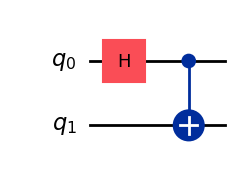

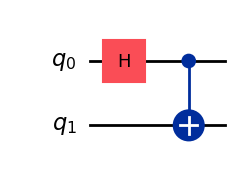

In [8]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)

qc.h(0)

qc.cx(0, 1)

qc.draw("mpl")


In [9]:

from qiskit.quantum_info import Statevector

state = Statevector.from_instruction(qc)

print("Statevector:")
print(state)

Statevector:
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


In [10]:
from qiskit_aer import Aer
from qiskit import transpile

qc_meas = qc.copy()
qc_meas.measure_all()

sim = Aer.get_backend('aer_simulator')
compiled = transpile(qc_meas, sim)
result = sim.run(compiled, shots=1024).result()

counts = result.get_counts()
print(counts)

{'00': 485, '11': 539}


## GHZ State Preparation

The GHZ state generalizes Bell states to multiple qubits:

$$|GHZ⟩ = \frac{|000\rangle + |111\rangle}{\sqrt{2}}$$

### Objective
To create multi-qubit entanglement.

### Method
- Apply Hadamard to the first qubit
- Apply a chain of CNOT gates

### Significance
GHZ states demonstrate non-classical correlations across multiple particles.


Construct the 3-qubit GHZ state:

$$
\frac{|000\rangle + |111\rangle}{\sqrt{2}}
$$


The task is to verify the state using simulation and then try to generalize the construction to an n-qubit GHZ state

---


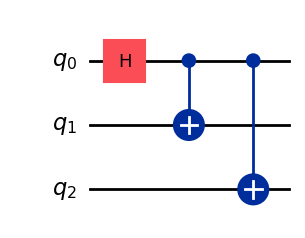

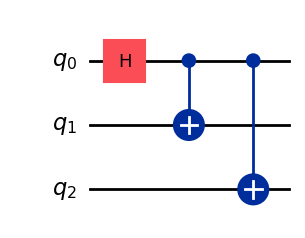

In [ ]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(3)

qc.h(0)

qc.cx(0, 1)
qc.cx(0, 2)

qc.draw("mpl")

In [12]:
from qiskit.quantum_info import Statevector

state = Statevector.from_instruction(qc)

print("Statevector:")
print(state)

Statevector:
Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.70710678+0.j],
            dims=(2, 2, 2))


In [ ]:
from qiskit_aer import Aer 
from qiskit import transpile 

qc_meas = qc.copy() 
qc_meas.measure_all() 

sim = Aer.get_backend('aer_simulator') 
compiled = transpile(qc_meas, sim)   
result = sim.run(compiled, shots=1024).result() 

counts = result.get_counts() 
print(counts)

{'111': 526, '000': 498}


In [ ]:
# General Code

def ghz(n): 
    qc = QuantumCircuit(n) 
    
    qc.h(0)  
    
    for i in range(1, n):
        qc.cx(0, i) 
    
    return qc 

## Quantum Interference

Quantum interference arises due to phase differences between amplitudes.

### Objective
To observe constructive and destructive interference.

### Method
- Apply Hadamard gates
- Introduce phase shifts
- Reapply Hadamard

### Insight
Interference determines the probability distribution of measurement outcomes and is central to quantum speedup.


## Phase Kickback

Construct a circuit demonstrating the phase kickback effect.

**Instructions:**

* Prepare a control qubit in superposition
* Apply a controlled phase rotation


This is to analyze how does the phase appears on the control qubits and to verify the effect using the statevector

---


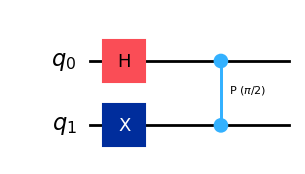

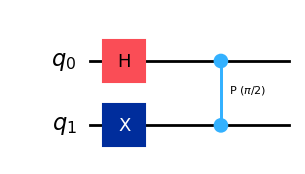

In [ ]:
from qiskit import QuantumCircuit
from numpy import pi 

qc = QuantumCircuit(2) 

qc.h(0) 

qc.x(1) 

qc.cp(pi/2, 0, 1)  
 
qc.draw("mpl") 

In [16]:
from qiskit.quantum_info import Statevector

state = Statevector.from_instruction(qc)

print("Statevector:")
print(state)

Statevector:
Statevector([0.00000000e+00+0.j        , 0.00000000e+00+0.j        ,
             7.07106781e-01+0.j        , 4.32978028e-17+0.70710678j],
            dims=(2, 2))


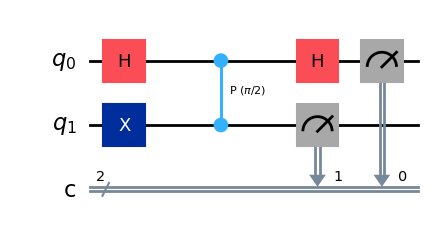

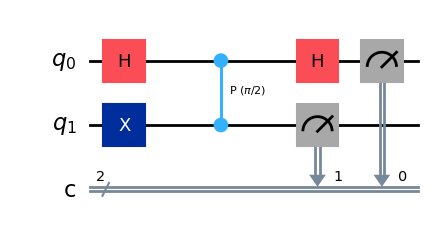

In [ ]:
from qiskit import QuantumCircuit
from numpy import pi

qc = QuantumCircuit(2,2)

# Putting the control in superposition
qc.h(0)

# Prepare target in |1> using X gate
qc.x(1)

# Apply the controlled phase gate
qc.cp(pi/2, 0, 1)

qc.h(0)

qc.measure([0,1], [0,1])

qc.draw("mpl")


## Interference 

Compare the following two circuits:

**Circuit A:**
$$
H \rightarrow Z \rightarrow H
$$

**Circuit B:**
$$
H \rightarrow H
$$


Here we have to simulate both the circuits and understand how does the Hadamard gate acts wheb applied twice and the action of Pauli Z gate. We can Compare their outputs and explain the role of quantum interference

---


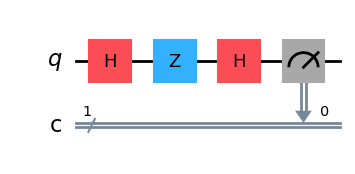

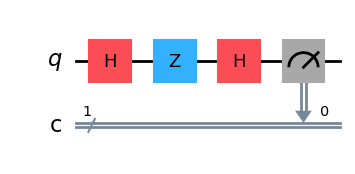

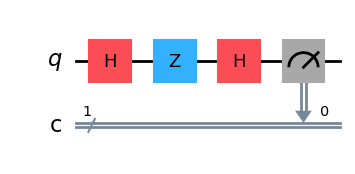

In [ ]:
from qiskit import QuantumCircuit

# Circuit A
qc_A = QuantumCircuit(1, 1)
qc_A.h(0)
qc_A.z(0)
qc_A.h(0)
qc_A.measure(0, 0)

# Circuit B
qc_B = QuantumCircuit(1, 1)
qc_B.h(0)
qc_B.h(0)
qc_B.measure(0, 0)

qc_A.draw("mpl")
qc_B.draw("mpl")


In [19]:

from qiskit_aer import Aer
from qiskit import transpile

sim = Aer.get_backend('aer_simulator')

# Run Circuit A
result_A = sim.run(transpile(qc_A, sim), shots=1024).result()
counts_A = result_A.get_counts()

# Run Circuit B
result_B = sim.run(transpile(qc_B, sim), shots=1024).result()
counts_B = result_B.get_counts()

print("Circuit A:", counts_A)
print("Circuit B:", counts_B)



Circuit A: {'1': 1024}
Circuit B: {'0': 1024}


## Quantum Fourier Transform (QFT)

The Quantum Fourier Transform is the quantum analogue of the discrete Fourier transform.

### Definition

QFT maps a quantum state |x⟩ to:

$$|x⟩ → \frac{1}{\sqrt{N}} \sum_{k=0}^{N-1} e^{2πixk/N} |k⟩$$

### Objective
To implement QFT for n-qubit systems.

### Method
- Apply Hadamard gates
- Apply controlled phase rotations
- Reverse qubit order

### Importance
QFT is a core subroutine in many quantum algorithms including Shor’s algorithm and QPE.


## Implement QFT (3 qubits)

Construct the Quantum Fourier Transform for 3 qubits.

**Instructions:**

* Use Hadamard, controlled-phase, and swap gates


Try to cerify it using the inbuilt function for the unitary matrix and compare with the theoretical QFT transformation result

---


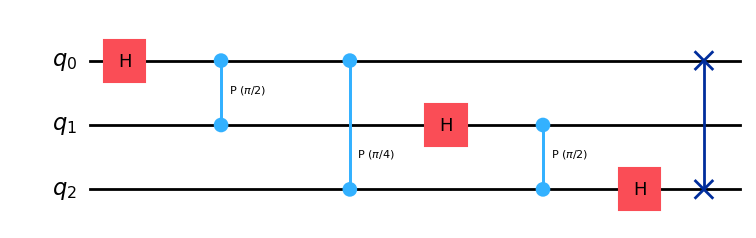

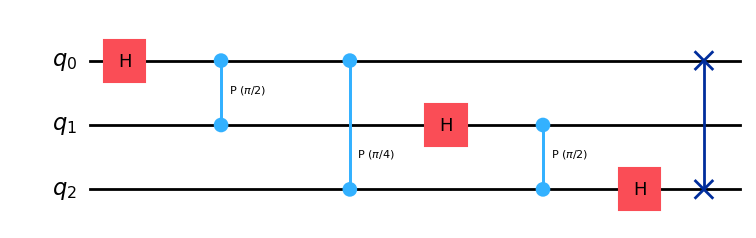

In [ ]:
from qiskit import QuantumCircuit
from numpy import pi

qc = QuantumCircuit(3)

qc.h(0)
qc.cp(pi/2, 1, 0)
qc.cp(pi/4, 2, 0)

qc.h(1)
qc.cp(pi/2, 2, 1)

qc.h(2)

qc.swap(0, 2)

qc.draw("mpl")

In [21]:
from qiskit.quantum_info import Operator
import numpy as np

U = Operator(qc).data
print(np.round(U, 3))

[[ 0.354+0.j     0.354+0.j     0.354+0.j     0.354+0.j     0.354+0.j
   0.354+0.j     0.354+0.j     0.354+0.j   ]
 [ 0.354+0.j     0.354+0.j     0.354+0.j     0.354+0.j    -0.354+0.j
  -0.354+0.j    -0.354+0.j    -0.354+0.j   ]
 [ 0.354+0.j     0.354+0.j    -0.354+0.j    -0.354+0.j     0.   +0.354j
   0.   +0.354j -0.   -0.354j -0.   -0.354j]
 [ 0.354+0.j     0.354+0.j    -0.354+0.j    -0.354+0.j    -0.   -0.354j
  -0.   -0.354j  0.   +0.354j  0.   +0.354j]
 [ 0.354+0.j    -0.354+0.j     0.   +0.354j -0.   -0.354j  0.25 +0.25j
  -0.25 -0.25j  -0.25 +0.25j   0.25 -0.25j ]
 [ 0.354+0.j    -0.354+0.j     0.   +0.354j -0.   -0.354j -0.25 -0.25j
   0.25 +0.25j   0.25 -0.25j  -0.25 +0.25j ]
 [ 0.354+0.j    -0.354+0.j    -0.   -0.354j  0.   +0.354j -0.25 +0.25j
   0.25 -0.25j   0.25 +0.25j  -0.25 -0.25j ]
 [ 0.354+0.j    -0.354+0.j    -0.   -0.354j  0.   +0.354j  0.25 -0.25j
  -0.25 +0.25j  -0.25 -0.25j   0.25 +0.25j ]]


In [22]:
from qiskit.quantum_info import Statevector

# Input: |001⟩
qc_test = QuantumCircuit(3)
qc_test.x(0)

qc_test = qc_test.compose(qc)

state = Statevector.from_instruction(qc_test)
print(state)

Statevector([ 0.35355339+0.j,  0.35355339+0.j,  0.35355339+0.j,
              0.35355339+0.j, -0.35355339+0.j, -0.35355339+0.j,
             -0.35355339+0.j, -0.35355339+0.j],
            dims=(2, 2, 2))



## Q7. Generalized QFT Function

Define and write a general function for QFT:

```python
def qft(n):
    ...
```

The task is to implement the QFT for an arbitrary n. We have to ensure the scalability and clarity of the circuit implementation.

---


In [ ]:
from qiskit import QuantumCircuit
from numpy import pi

def qft(n): 
    qc = QuantumCircuit(n) 
    
    # Apply Hadamard to start the QFT
    for j in range(n): 
        qc.h(j) 
        
        for k in range(j+1, n):
            angle = pi / (2 ** (k - j))   # Mathematically this turns out to be the definition of the angle while detiving the QFT from the cery first principles 
            qc.cp(angle, k, j)            # And this wil give the controlled phase factor for each qubit on |1>
              
    
    # Swap qubits have to be applied to reverse the order of qubits
    for i in range(n // 2):
        qc.swap(i, n - i - 1)
    
    return qc 

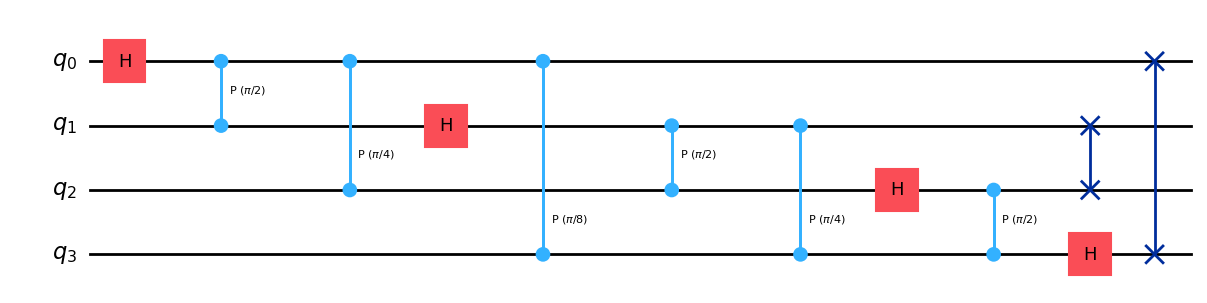

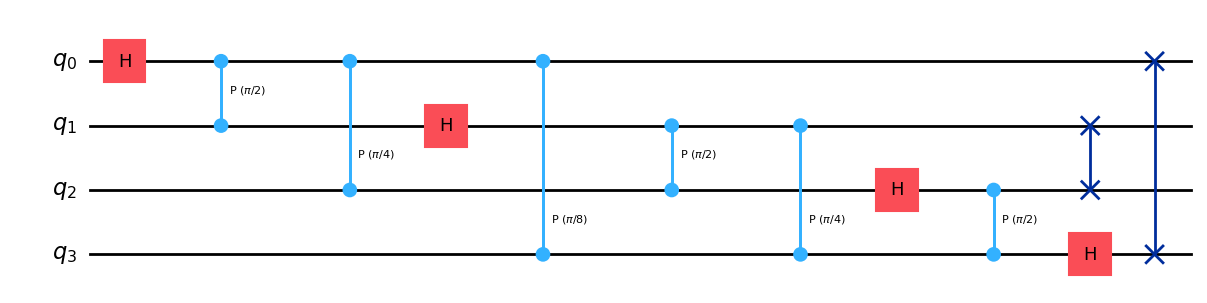

In [ ]:
from qiskit import QuantumCircuit
from numpy import pi

def qft(n):
    qc = QuantumCircuit(n)
    
    for j in range(n):
        qc.h(j)
        
        for k in range(j+1, n):
            angle = pi / (2 ** (k - j))
            qc.cp(angle, k, j)
    
    for i in range(n // 2):
        qc.swap(i, n - i - 1)
    
    return qc

qc = qft(4)
qc.draw("mpl")

In [25]:
from qiskit.quantum_info import Statevector

qc_test = QuantumCircuit(3)
qc_test.x(1)  # example input

qc_total = qc_test.compose(qft(3))

state = Statevector.from_instruction(qc_total)
print(state)

Statevector([ 3.53553391e-01+0.j        ,  3.53553391e-01+0.j        ,
             -3.53553391e-01+0.j        , -3.53553391e-01+0.j        ,
              2.16489014e-17+0.35355339j,  2.16489014e-17+0.35355339j,
             -2.16489014e-17-0.35355339j, -2.16489014e-17-0.35355339j],
            dims=(2, 2, 2))


In [26]:
def qft(n):
    qc = QuantumCircuit(n)
    
    for j in range(n):
        qc.h(j)
        for k in range(j+1, n):
            qc.cp(pi / 2**(k-j), k, j)
    
    qc.swap(range(n//2), reversed(range(n//2)))
    
    return qc

## Inverse Quantum Fourier Transform (IQFT)

The inverse QFT reverses the transformation performed by QFT.

### Objective
To reconstruct the original state from the Fourier basis.

### Method
- Reverse the sequence of gates in QFT
- Use conjugate phase rotations

### Role
IQFT is essential in extracting classical information from quantum phase encoding.


Construct the inverse Quantum Fourier Transform.

**Instructions:**

* Do not use built-in `.inverse()`
* Reverse gate order and use negative phase angles


In [ ]:
from qiskit import QuantumCircuit
from numpy import pi

def iqft(n):
    qc = QuantumCircuit(n)
    
    # First the swap gates have to be applied
    for i in range(n // 2):
        qc.swap(i, n - i - 1)
    
    # Apply the inverse operations
    for j in reversed(range(n)):
        
        # Controlled phase on reverse order with negative angles
        for k in reversed(range(j+1, n)):
            qc.cp(-pi / (2 ** (k - j)), k, j)
        
        # Hadamard on each qubit
        qc.h(j)
    
    return qc

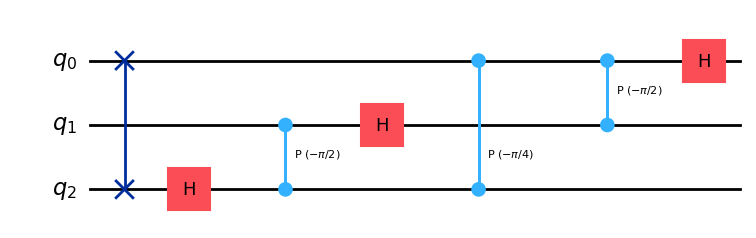

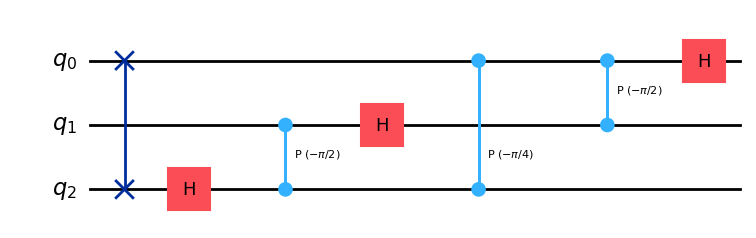

In [ ]:
from qiskit import QuantumCircuit
from numpy import pi 

def iqft(n):
    qc = QuantumCircuit(n) 
    
    # Reverse swap to recerse the order 
    for i in range(n // 2): 
        qc.swap(i, n - i - 1) 
    
    # Apply inverse operations
    for j in reversed(range(n)): 
        
        # Controlled phase reverse order and negative angles)
        for k in reversed(range(j+1, n)): 
            qc.cp(-pi / (2 ** (k - j)), k, j) 
        
        qc.h(j) 
    
    return qc 

qc = iqft(3) 
qc.draw("mpl") 

In [ ]:
from qiskit.quantum_info import Operator 
import numpy as np 

U_qft = Operator(qft(3)).data 
U_iqft = Operator(iqft(3)).data        

# This should give identity 
print(np.round(U_qft @ U_iqft, 3)) 

CircuitError: 'duplicate qubit arguments'

## Quantum Phase Estimation (QPE)

QPE is used to estimate the eigenvalue (phase) of a unitary operator.

### Problem Statement

Given a unitary operator U and eigenvector |ψ⟩ such that:

$$U|ψ⟩ = e^{2πiθ}|ψ⟩$$

the goal is to estimate θ.

### Method
1. Initialize counting qubits in superposition
2. Apply controlled-U operations
3. Apply inverse QFT
4. Measure to obtain θ

### Importance
QPE is central to algorithms like Shor’s factoring and quantum simulation.


## Single-Qubit Phase Estimation

Consider the unitary operator:

$$
U =
\begin{bmatrix}
1 & 0 \
0 & e^{2\pi i \theta}
\end{bmatrix}
$$


The task is to implement the Quantum Phase Estimation algorithm then extract and interpret the value of $\theta$. In principle, we are actually finding the eigenvalue of the unitary which can be found by obtaining the value of $\theta$.

---


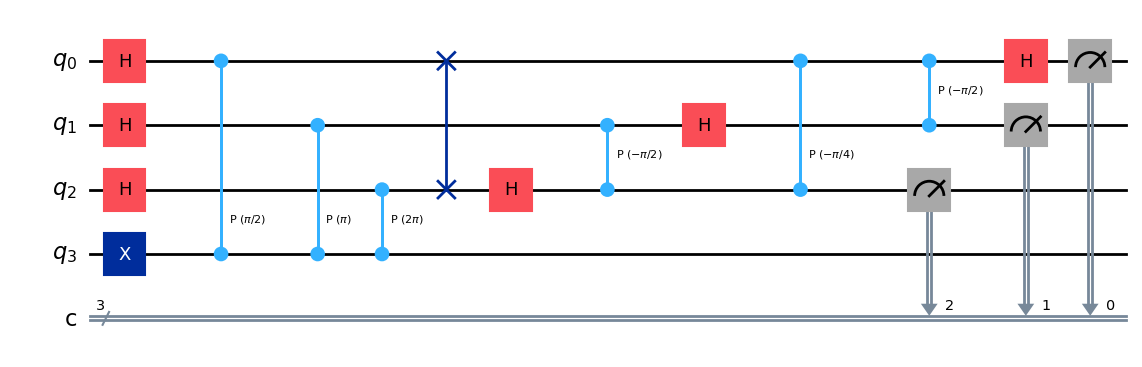

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from numpy import pi 

# Number of counting qubits taken as 3 
n = 3 

qc = QuantumCircuit(n+1, n) 

# Hadamard on counting qubits 
for i in range(n): 
    qc.h(i) 

# Prepare eigenstate |1> by applying the X gate 
qc.x(n)

# Controlled-U^(2^k) in Phase estimation for Phase kickback
# U = phase gate with angle 2πθ = π/2

for i in range(n):
    angle = (2**i) * (pi/2)
    qc.cp(angle, i, n)

# Apply Inverse QFT 
from numpy import pi 

def iqft(n): 
    qc_i = QuantumCircuit(n)  
    
    for i in range(n//2):  
        qc_i.swap(i, n-i-1) 
    
    for j in reversed(range(n)): 
        for k in reversed(range(j+1, n)): 
            qc_i.cp(-pi/(2**(k-j)), k, j) 
        qc_i.h(j) 
    
    return qc_i 

qc = qc.compose(iqft(n), range(n)) 

# Measurement
qc.measure(range(n), range(n))

qc.draw("mpl")

In [ ]:
sim = Aer.get_backend('aer_simulator')
compiled = transpile(qc, sim)

result = sim.run(compiled, shots=1024).result()
counts = result.get_counts()

print(counts)

{'010': 249, '110': 47, '011': 274, '100': 223, '111': 198, '101': 33}


n=2, estimate=0.7500, error=0.4500
n=3, estimate=0.7500, error=0.4500
n=4, estimate=0.7500, error=0.4500
n=5, estimate=0.3438, error=0.0438
n=6, estimate=0.3438, error=0.0438
n=7, estimate=0.3438, error=0.0438
n=8, estimate=0.3477, error=0.0477


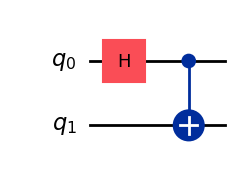

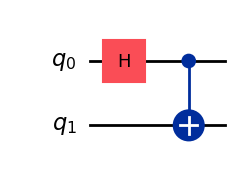

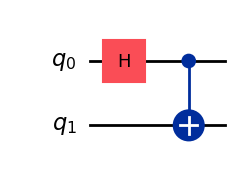

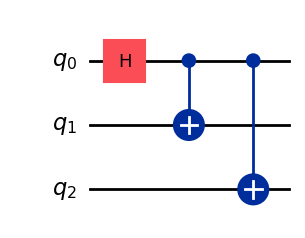

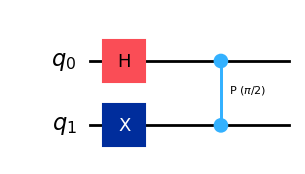

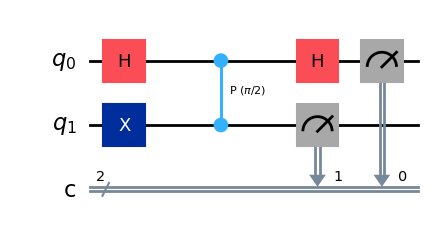

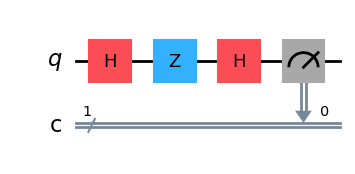

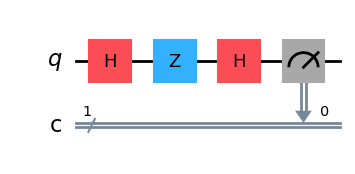

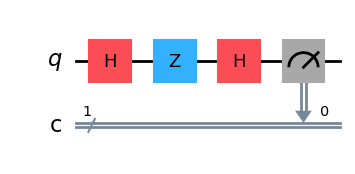

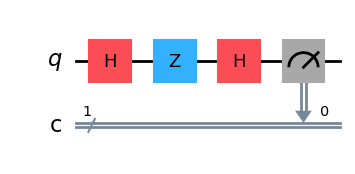

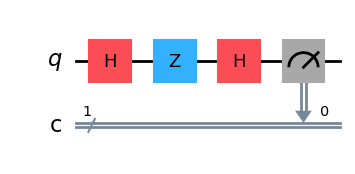

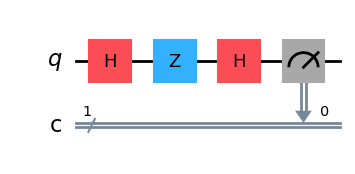

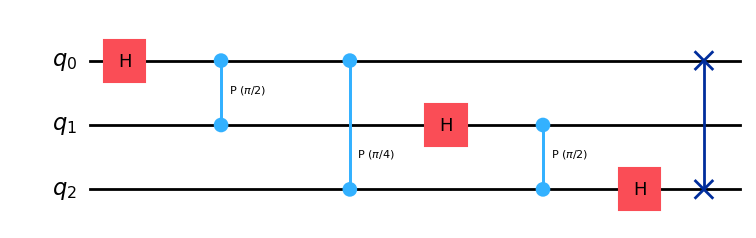

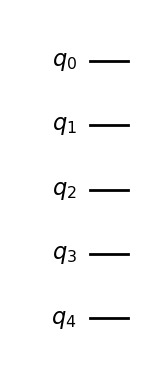

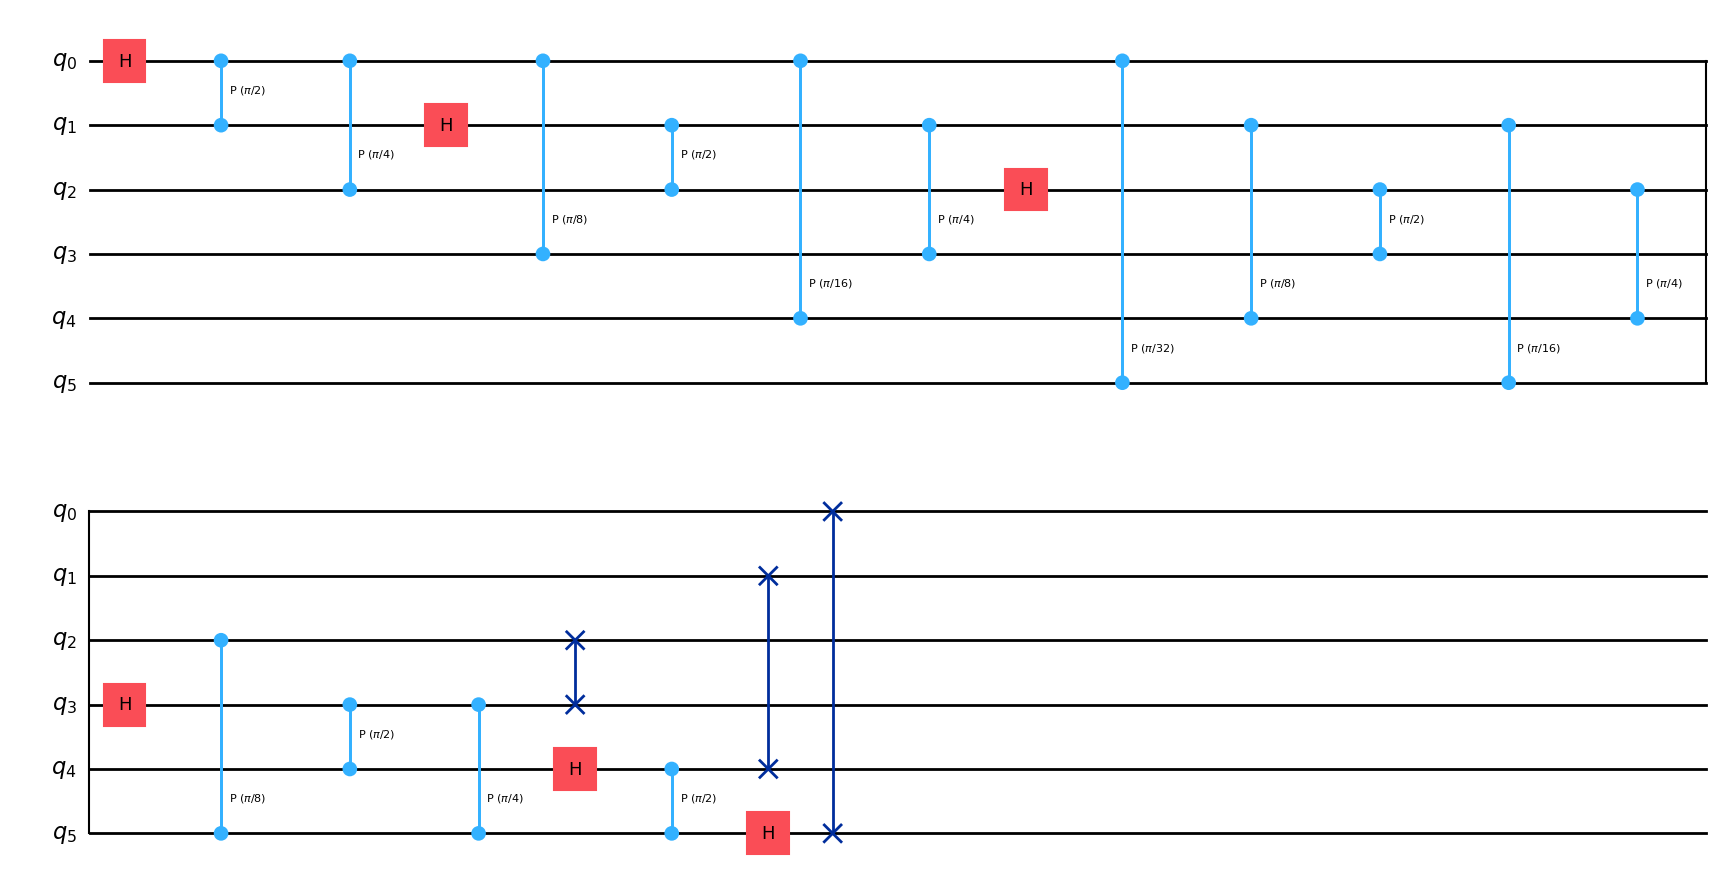

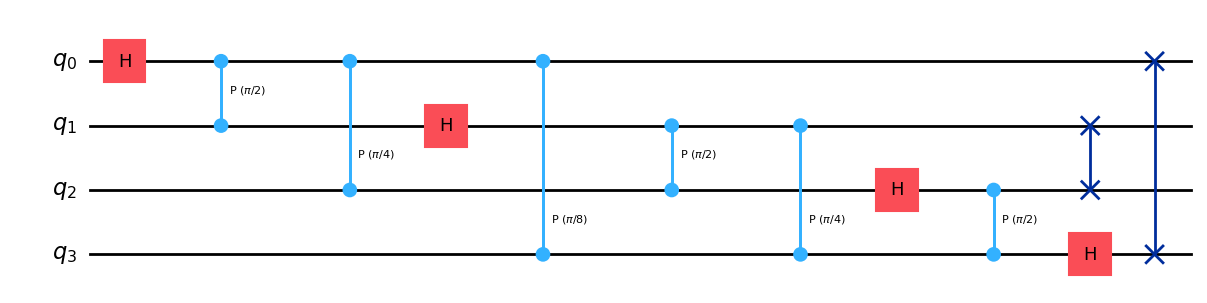

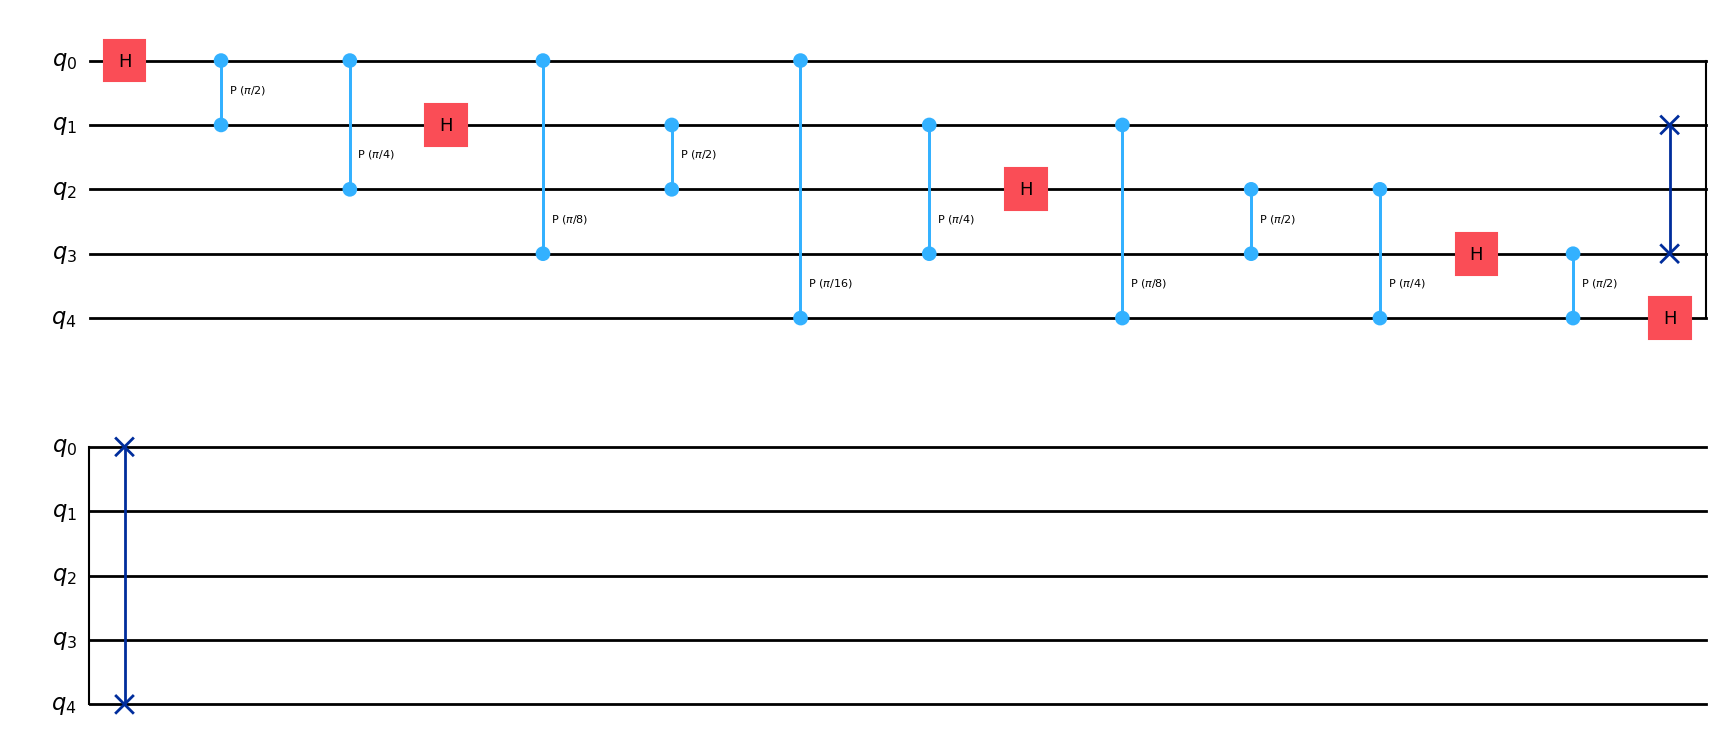

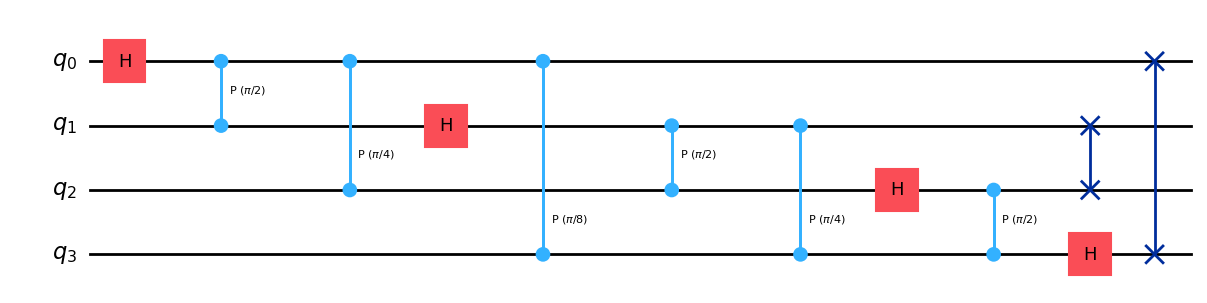

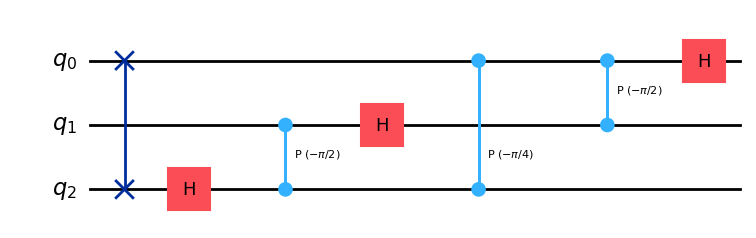

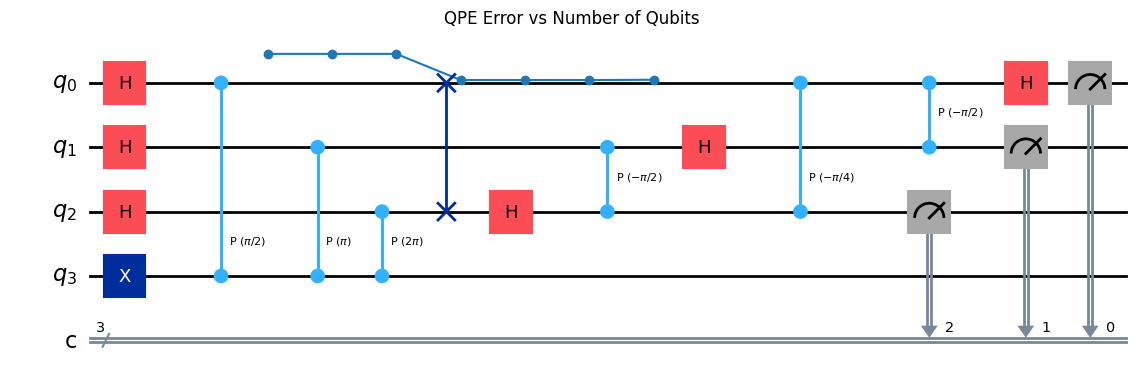

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from numpy import pi
import numpy as np
import matplotlib.pyplot as plt 

# True phase just for an exxample (choose non-exact binary) 
theta = 0.3   

def iqft(n): 
    qc = QuantumCircuit(n) 
    
    for i in range(n//2):  
        qc.swap(i, n-i-1)  
    
    for j in reversed(range(n)):  
        for k in reversed(range(j+1, n)):  
            qc.cp(-pi/(2**(k-j)), k, j) 
        qc.h(j)  
    
    return qc

def qpe_circuit(n, theta):
    qc = QuantumCircuit(n+1, n)
    
    # Superposition in the last 
    for i in range(n): 
        qc.h(i)  
    
    qc.x(n)
    
    # Controlled-U^(2^k)
    for i in range(n):
        angle = 2 * pi * theta * (2**i)
        qc.cp(angle, i, n)
    
    # IQFT
    qc = qc.compose(iqft(n), range(n))
    
    # Measurement
    qc.measure(range(n), range(n))
    
    return qc

def run_qpe(n):
    qc = qpe_circuit(n, theta)
    
    sim = Aer.get_backend('aer_simulator')
    compiled = transpile(qc, sim)
    
    result = sim.run(compiled, shots=1024).result()
    counts = result.get_counts()
    
    # Get the most probable result
    measured = max(counts, key=counts.get) 
    
    # Convert the phase from binary to decimal
    decimal = int(measured, 2) / (2**n) 
    
    error = abs(theta - decimal) 
    
    return decimal, error 

# Run for different n
n_values = list(range(2, 9)) 
errors = []
estimates = [] 

for n in n_values: 
    est, err = run_qpe(n) 
    estimates.append(est)  
    errors.append(err) 
    print(f"n={n}, estimate={est:.4f}, error={err:.4f}")   

plt.plot(n_values, errors, marker='o')
plt.xlabel("Number of qubits (n)")
plt.ylabel("Error")
plt.title("QPE Error vs Number of Qubits")
plt.grid()
plt.show()


## QPE with Known Eigenstate

Use the unitary:

$$
U = R_z(\phi)
$$

The point is to choose an appropriate eigenstate and then recover the phase using QPE

---


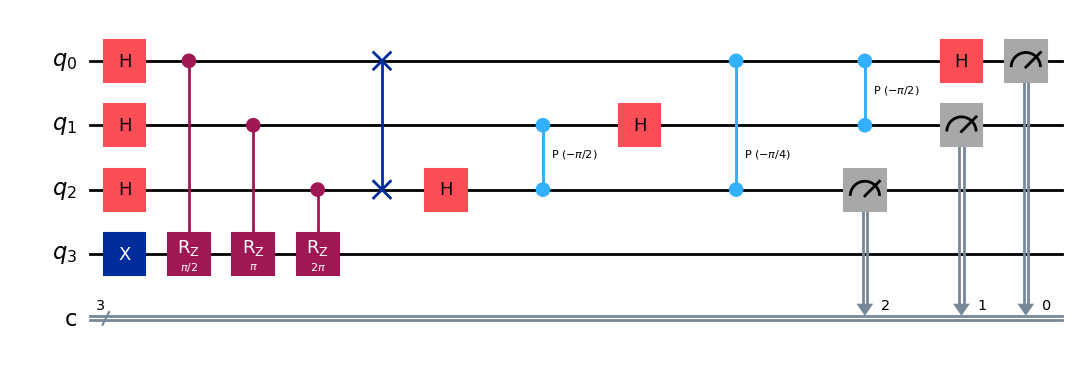

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from numpy import pi 

# Choose value of phi
phi = pi / 2   

# Take number of counting qubits as 3
n = 3 

qc = QuantumCircuit(n+1, n) 

for i in range(n): 
    qc.h(i) 

qc.x(n) 

for i in range(n): 
    angle = phi * (2**i) 
    qc.crz(angle, i, n)  

# IQFT starts here 
def iqft(n):
    qc_i = QuantumCircuit(n)
    
    for i in range(n//2):
        qc_i.swap(i, n-i-1)
    
    for j in reversed(range(n)):
        for k in reversed(range(j+1, n)):
            qc_i.cp(-pi/(2**(k-j)), k, j)
        qc_i.h(j)
    
    return qc_i

qc = qc.compose(iqft(n), range(n))

qc.measure(range(n), range(n))

qc.draw("mpl")

In [ ]:
sim = Aer.get_backend('aer_simulator')
compiled = transpile(qc, sim)

result = sim.run(compiled, shots=1024).result()
counts = result.get_counts()

print(counts)

{'001': 455, '101': 123, '100': 29, '011': 201, '010': 216}


## Precision and Approximation in QPE

### Objective
To study how the number of qubits affects accuracy.

### Observation
- Increasing the number of counting qubits improves precision
- Approximate QFT reduces circuit depth but introduces small errors

### Trade-off
There is a balance between computational resources and estimation accuracy.



Vary the number of counting qubits and analyze how the precision QPE depends on qubit count. Plot the estimation error.

---


n=2, estimate=0.75000, error=0.45000
n=3, estimate=0.75000, error=0.45000
n=4, estimate=0.75000, error=0.45000
n=5, estimate=0.34375, error=0.04375
n=6, estimate=0.34375, error=0.04375
n=7, estimate=0.34375, error=0.04375
n=8, estimate=0.34766, error=0.04766


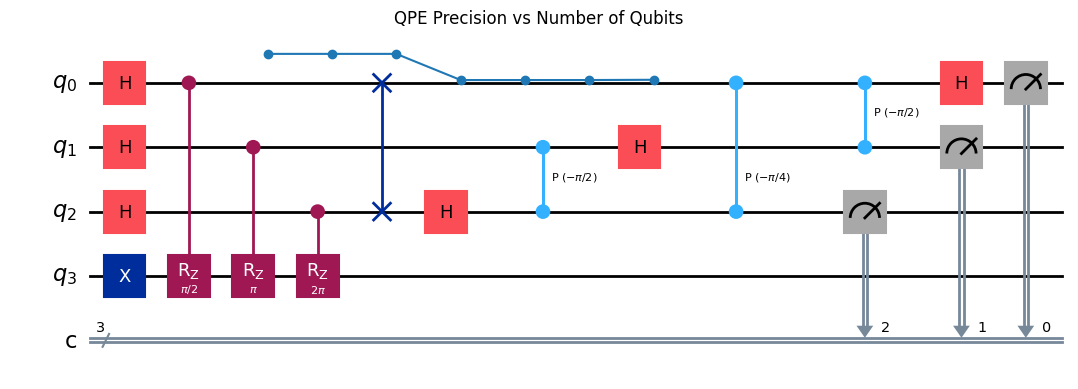

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from numpy import pi
import numpy as np
import matplotlib.pyplot as plt 

theta = 0.3 

def iqft(n): 
    qc = QuantumCircuit(n) 
    
    for i in range(n//2): 
        qc.swap(i, n-i-1)
    
    for j in reversed(range(n)): 
        for k in reversed(range(j+1, n)):
            qc.cp(-pi/(2**(k-j)), k, j)
        qc.h(j) 
    
    return qc 

def qpe(n, theta):
    qc = QuantumCircuit(n+1, n)
    
    for i in range(n):
        qc.h(i)
    
    qc.x(n)
    
    # Controlled phase operations 
    for i in range(n): 
        qc.cp(2*pi*theta*(2**i), i, n) 
    
    # IQFT
    qc = qc.compose(iqft(n), range(n))
    
    # Measurement 
    qc.measure(range(n), range(n)) 
    
    return qc 

def run_qpe(n): 
    qc = qpe(n, theta)
    
    sim = Aer.get_backend('aer_simulator')
    compiled = transpile(qc, sim) 
    
    result = sim.run(compiled, shots=1024).result() 
    counts = result.get_counts() 
    
    measured = max(counts, key=counts.get) 
    estimate = int(measured, 2) / (2**n) 
    
    error = abs(theta - estimate)
    
    return estimate, error 

# Run the experiment 
n_values = range(2, 9) 
errors = [] 
estimates = []

for n in n_values: 
    est, err = run_qpe(n) 
    estimates.append(est)
    errors.append(err) 
    print(f"n={n}, estimate={est:.5f}, error={err:.5f}") 


plt.plot(n_values, errors, marker='o')
plt.xlabel("Number of Qubits (n)")
plt.ylabel("Error")
plt.title("QPE Precision vs Number of Qubits")
plt.grid()
plt.show()



## Approximate QFT (AQFT)

Construct an approximate version of QFT by neglecting small-angle rotations.

The task here compare the accuracy with full QFT and analyze computational trade-offs

---


In [ ]:
from qiskit import QuantumCircuit
from numpy import pi

def aqft(n, m):
    qc = QuantumCircuit(n)
    
    for j in range(n):
        qc.h(j)
        
        # This min function only include nearby qubits
        for k in range(j+1, min(n, j+m+1)):  
            angle = pi / (2**(k-j)) 
            qc.cp(angle, k, j)  
    
    # Swap
    for i in range(n//2):
        qc.swap(i, n-i-1)
    
    return qc

qc_full = qft(5)
qc_approx = aqft(5, m=2)

print("Full QFT depth:", qc_full.depth())
print("AQFT depth:", qc_approx.depth())

Full QFT depth: 10
AQFT depth: 10


In [ ]:
from qiskit.quantum_info import Statevector
import numpy as np 

qc_input = QuantumCircuit(5) 
qc_input.h(range(5)) 

# Apply the transforms 
state_full = Statevector.from_instruction(qc_input.compose(qft(5)))
state_approx = Statevector.from_instruction(qc_input.compose(aqft(5, 2)))

# Fidelity measure
fidelity = np.abs(np.dot(state_full.data.conj(), state_approx.data))**2

print("Fidelity:", fidelity)

Fidelity: 0.9999999999999969




## Complete QPE 

Construct a complete QPE implementation including the state preparation, controlled unitary operations, and the inverse QFT

---


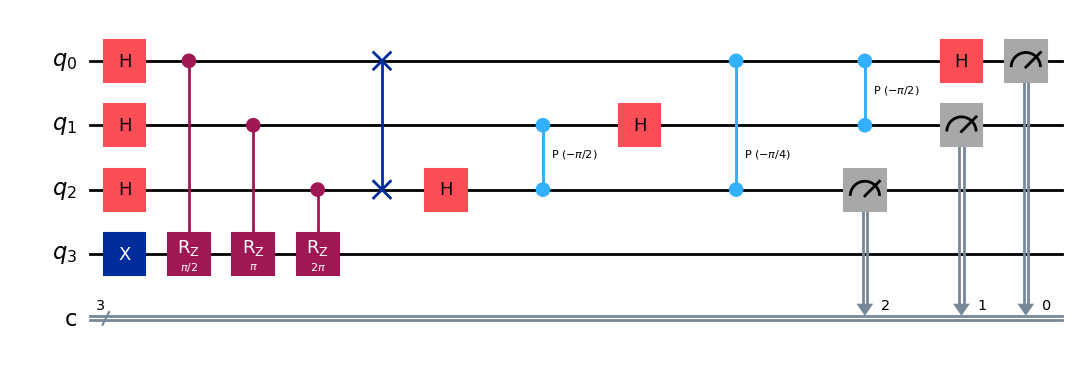

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from numpy import pi 

n = 3  

qc = QuantumCircuit(n+1, n) 

# Hadamard 
for i in range(n): 
    qc.h(i) 

# Prepare eigenstate |1> 
qc.x(n) 

# Controlled unitary U^(2^k) 
for i in range(n): 
    qc.crz(phi * (2**i), i, n)  

# IQFT 
def iqft(n):
    qc_i = QuantumCircuit(n) 
    
    for i in range(n//2): 
        qc_i.swap(i, n-i-1) 
    
    for j in reversed(range(n)): 
        for k in reversed(range(j+1, n)):  
            qc_i.cp(-pi/(2**(k-j)), k, j) 
        qc_i.h(j) 
    
    return qc_i 

qc = qc.compose(iqft(n), range(n)) 

# Measurement 
qc.measure(range(n), range(n)) 

qc.draw("mpl")

In [ ]:
sim = Aer.get_backend('aer_simulator')
compiled = transpile(qc, sim)

result = sim.run(compiled, shots=1024).result()
counts = result.get_counts()

print(counts)

{'011': 212, '001': 426, '101': 140, '010': 225, '100': 21}


In [ ]:
#Generalised function

def qpe_full(n, phi):
    qc = QuantumCircuit(n+1, n)
    
    for i in range(n):
        qc.h(i)
    
    qc.x(n)
    
    for i in range(n):
        qc.crz(phi * (2**i), i, n)
    
    qc = qc.compose(iqft(n), range(n))
    qc.measure(range(n), range(n))
    
    return qc


## Period Finding

Implement a simple example of period finding (core idea behind Shor’s algorithm).

---


In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from numpy import pi 

n = 3   

qc = QuantumCircuit(n+1, n) 

# Hadamard 
for i in range(n):
    qc.h(i)

qc.x(n)

# simulate the eigenvalue e^{2πi/4} 
theta = 1/4 

for i in range(n): 
    qc.cp(2*pi*theta*(2**i), i, n) 

# IQFT 
def iqft(n): 
    qc_i = QuantumCircuit(n) 
    
    for i in range(n//2): 
        qc_i.swap(i, n-i-1)
    
    for j in reversed(range(n)):
        for k in reversed(range(j+1, n)): 
            qc_i.cp(-pi/(2**(k-j)), k, j)
        qc_i.h(j)
    
    return qc_i

qc = qc.compose(iqft(n), range(n))  

# measurement 
qc.measure(range(n), range(n) 

)

In [ ]:
sim = Aer.get_backend('aer_simulator')
compiled = transpile(qc, sim)

result = sim.run(compiled, shots=1024).result()
counts = result.get_counts()

print(counts)

{'010': 281, '100': 212, '011': 224, '110': 42, '111': 219, '101': 46}


In [ ]:
# Qiskit implementation (modular multiplication)

from qiskit import QuantumCircuit
from qiskit.extensions import UnitaryGate
import numpy as np

def mod_mult_unitary(a, N, n_qubits):
    dim = 2**n_qubits
    U = np.zeros((dim, dim))
    
    for x in range(dim):
        if x < N:
            y = (a * x) % N
        else:
            y = x
        
        U[y][x] = 1
    
    return UnitaryGate(U)

ModuleNotFoundError: No module named 'qiskit.extensions'

In [ ]:
# Controlled modular multiplication

def controlled_mod_mult(qc, control, target_qubits, a, N):
    U = mod_mult_unitary(a, N, len(target_qubits))
    cU = U.control()
    
    qc.append(cU, [control] + target_qubits)

In [ ]:
# modular exponentiation

def modular_exponentiation(qc, counting_qubits, target_qubits, a, N):
    
    for i, q in enumerate(counting_qubits):
        power = pow(a, 2**i, N)
        
        controlled_mod_mult(qc, q, target_qubits, power, N)

In [ ]:
n_count = 3
n_target = 4  # enough for N=15

qc = QuantumCircuit(n_count + n_target)

counting = list(range(n_count))
target = list(range(n_count, n_count + n_target))

for q in counting:
    qc.h(q)

# Initialize the |1>
qc.x(target[0])

# Modular exponentiation 
modular_exponentiation(qc, counting, target, a=2, N=15)

qc.draw("mpl")

NameError: name 'modular_exponentiation' is not defined

## Results and Insights

- Bell and GHZ states confirmed strong quantum correlations
- Interference patterns demonstrated the role of phase in probability amplitudes
- QFT successfully transformed computational basis states into phase space
- QPE showed that phase estimation accuracy increases with number of qubits

### Key Insight
Quantum algorithms rely heavily on interference and phase encoding rather than direct computation, distinguishing them fundamentally from classical algorithms.